---
## Sección 0 — Importar librerías

In [1]:
# ── Datos y cálculo ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualización ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Partición y validación ───────────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split,       # separar train y test en un solo corte
    KFold,                  # K-Fold estándar (observaciones independientes)
    StratifiedKFold,        # K-Fold estratificado (clases desbalanceadas)
    cross_val_score,        # ejecutar CV y obtener métricas por fold
    GroupKFold,             # K-Fold con grupos (mismo cliente en mismo fold)
    cross_validate,         # CV con múltiples métricas a la vez
)

# ── Preprocesamiento ─────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ── MODELOS — los mismos que ya conoces ──────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier
)
from sklearn.svm import SVR, SVC
from sklearn.neural_network import MLPRegressor, MLPClassifier

# ── Métricas ──────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,   # regresión
    accuracy_score, f1_score, roc_auc_score,              # clasificación
    confusion_matrix
)

# ── Configuración ─────────────────────────────────────────────────────────────
np.random.seed(42)
plt.rcParams.update({'figure.figsize': (14, 5), 'font.size': 11})

print("✅ Librerías importadas.")

✅ Librerías importadas.


---
## Sección 1 — Generar el portafolio de seguros

In [2]:
N = 2000   # total de pólizas

# ── Variables del asegurado y del vehículo ───────────────────────────────────
edad              = np.random.randint(18, 75, N)
zona              = np.random.randint(1, 6, N)         # 1=bajo riesgo, 5=muy alto
anios_vehiculo    = np.random.randint(0, 20, N)
cobertura         = np.random.choice([0, 1, 2], N, p=[0.30, 0.35, 0.35])
historial         = np.random.choice([0, 1, 2, 3, 4], N, p=[0.50, 0.28, 0.14, 0.05, 0.03])

# ── Prima pura: relación no lineal (curva en U según edad, zona no lineal) ───
prima_pura = np.clip(
    5000
    + 200  * zona**1.3
    - 40   * (edad - 40)**2 / 100
    + 150  * anios_vehiculo
    + 3000 * cobertura
    + 800  * historial
    + np.random.normal(0, 2500, N),
    1500, None
)

# ── Probabilidad de siniestro: logística de las variables ───────────────────
# La probabilidad base es ~22%, sube con zona, historial y cobertura amplia
log_odds = (
    -1.2
    + 0.28 * zona
    + 0.45 * historial
    + 0.15 * cobertura
    + 0.008 * anios_vehiculo
    - 0.005 * (edad - 40)**2 / 100
)
prob_siniestro = 1 / (1 + np.exp(-log_odds))
tuvo_siniestro = (np.random.rand(N) < prob_siniestro).astype(int)

# ── Armar DataFrame ──────────────────────────────────────────────────────────
df = pd.DataFrame({
    'edad': edad, 'zona': zona, 'anios_vehiculo': anios_vehiculo,
    'cobertura': cobertura, 'historial_siniestros': historial,
    'prima_pura': prima_pura.round(2),
    'tuvo_siniestro': tuvo_siniestro
})

# ── Variables predictoras ─────────────────────────────────────────────────────
FEATURES = ['edad', 'zona', 'anios_vehiculo', 'cobertura', 'historial_siniestros']
X = df[FEATURES].values
y_reg  = df['prima_pura'].values        # objetivo de regresión
y_clas = df['tuvo_siniestro'].values    # objetivo de clasificación

# ── Resumen ──────────────────────────────────────────────────────────────────
print(f"Dataset: {N:,} pólizas × {len(FEATURES)} variables")
print(f"\nPrima pura:       media=${prima_pura.mean():,.0f}  std=${prima_pura.std():,.0f}")
print(f"Pólizas con siniestro: {tuvo_siniestro.sum():,} ({tuvo_siniestro.mean()*100:.1f}%)")
print(f"Sin siniestro:         {(1-tuvo_siniestro).sum():,} ({(1-tuvo_siniestro).mean()*100:.1f}%)")
print("\nPrimeras 5 filas:")
print(df.head())

Dataset: 2,000 pólizas × 5 variables

Prima pura:       media=$10,940  std=$3,756
Pólizas con siniestro: 1,096 (54.8%)
Sin siniestro:         904 (45.2%)

Primeras 5 filas:
   edad  zona  anios_vehiculo  cobertura  historial_siniestros  prima_pura  \
0    56     5              14          1                     0    12911.33   
1    69     3              18          0                     1    12164.95   
2    46     2               8          0                     2     3192.44   
3    32     3              10          0                     1     5003.01   
4    60     2               7          1                     0    10667.58   

   tuvo_siniestro  
0               1  
1               1  
2               0  
3               1  
4               1  


---
## Sección 2 — Por qué el error en train no es el error real

### La pregunta clave

Ya sabes que un Random Forest y un GBM generalmente superan a una Regresión Lineal en capacidad predictiva. Pero, ¿cómo sabes **cuánto** mejor son? ¿Y cómo detectas cuando un modelo aprendió demasiado bien los datos de entrenamiento?

La respuesta está en comparar el error en **train** vs. el error en **test**.

In [3]:
# ── Separar PRIMERO (regla fundamental de la Sección 1.4 de la guía) ─────────
# Siempre antes de cualquier transformación o análisis estadístico
X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg,
    test_size=0.20,    # 80% train, 20% test
    random_state=42    # semilla fija: todos obtenemos la misma partición
)

print(f"Train: {len(X_train):,} pólizas ({len(X_train)/N*100:.0f}%)")
print(f"Test:  {len(X_test):,} pólizas  ({len(X_test)/N*100:.0f}%)")

# ── Scaler: fit SOLO en train, transform en ambos ────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # aprende μ y σ del train
X_test_sc  = scaler.transform(X_test)       # aplica los mismos μ y σ

print(f"\nMedia del scaler (aprendida del train):")
for f, m in zip(FEATURES, scaler.mean_):
    print(f"  {f:22s}: {m:.2f}")

Train: 1,600 pólizas (80%)
Test:  400 pólizas  (20%)

Media del scaler (aprendida del train):
  edad                  : 46.64
  zona                  : 3.04
  anios_vehiculo        : 9.81
  cobertura             : 1.04
  historial_siniestros  : 0.80


In [13]:
# ── Comparar 6 modelos que ya conoces: error en TRAIN vs. TEST ───────────────
# El objetivo es observar el patrón, no optimizar los hiperparámetros

modelos_reg = {
    'Regresión Lineal':        LinearRegression(),
    'Ridge (λ=50)':            Ridge(alpha=50),
    'Árbol (sin poda)':        DecisionTreeRegressor(random_state=42),
    'Árbol (max_depth=5)':     DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest':           RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':       GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42),
}

resultados = []

#print(f"{'Modelo':26s}  {'MAE Train':>11}  {'MAE Test':>10}  {'Diferencia':>12}  {'Diagnóstico'}")
#print("-" * 90)

print(
    f"{'Modelo':26s}  "
    f"{'MAE Train':>11}  "
    f"{'MAE Test':>10}  "
    f"{'Dif. MAE':>10}  "
    f"{'RMSE Train':>12}  "
    f"{'RMSE Test':>11}  "
    f"{'Dif. RMSE':>10}  "
    f"{'R² Train':>9}  "
    f"{'R² Test':>8}  "
    f"{'Dif. R²':>8}  "
    f"{'Diagnóstico'}"
)

for nombre, modelo in modelos_reg.items():
    modelo.fit(X_train_sc, y_train)
    pred_train = modelo.predict(X_train_sc)
    pred_test = modelo.predict(X_test_sc)


    mae_train = mean_absolute_error(y_train, modelo.predict(X_train_sc))
    mae_test  = mean_absolute_error(y_test,  modelo.predict(X_test_sc))
    r2_train  = r2_score(y_train, modelo.predict(X_train_sc))
    r2_test   = r2_score(y_test,  modelo.predict(X_test_sc))
    mse_train = mean_squared_error(y_train, pred_train)
    mse_test = mean_squared_error(y_test, pred_test)
    rmse_train = np.sqrt(mse_train)
    rmse_test = np.sqrt(mse_test)
    diferencia = mae_test - mae_train
    diferencia_rmse = rmse_test - rmse_train
    diferencia_r2 = r2_train - r2_test

    # Diagnóstico automático (Sección 1.3 de la guía)
    if mae_train > 3500:
        diag = "⚠️  UNDERFITTING — modelo demasiado simple"
    elif diferencia / mae_train > 0.30:
        diag = "🔴 OVERFITTING — memoriza el ruido"
    elif diferencia / mae_train > 0.12:
        diag = "⚠️  Varianza alta — revisar regularización"
    elif diferencia_r2 > 0.15:
        diag = "🔴 OVERFITTING"
    elif r2_train < 0.25:
        diag = "⚠️  UNDERFITTING"
    else:
        diag = "✅ Buen balance sesgo-varianza"

    resultados.append({'modelo': nombre, 'mae_train': mae_train, 'mae_test': mae_test, 'diferencia': diferencia,
                       'r2_train': r2_train, 'r2_test': r2_test, "dif_r2": diferencia_r2,
                       "rmse_train": rmse_train, "rmse_test": rmse_test, "dif_rmse": diferencia_rmse,
                        "diagnostico": diag})

    #print(f"{nombre:26s}  ${mae_train:>9,.0f}  ${mae_test:>8,.0f}  ${diferencia:>+10,.0f}  {diag}")
    print(
        f"{nombre:26s}  "
        f"${mae_train:>9,.0f}  "
        f"${mae_test:>8,.0f}  "
        f"${diferencia:>+8,.0f}  "
        f"${rmse_train:>10,.0f}  "
        f"${rmse_test:>9,.0f}  "
        f"{diferencia_rmse:>+8.4f}  "
        f"{r2_train:>9.4f}  "
        f"{r2_test:>8.4f}  "
        f"{diferencia_r2:>+8.4f}  "
        f"{diag}"
    )

df_res = pd.DataFrame(resultados)



print()
print("CONCLUSIÓN CLAVE:")
print("  El Árbol SIN PODA tiene MAE_train cercano a 0 pero el mayor MAE_test.")
print("  Esto es OVERFITTING: memorizó las 1,600 pólizas de train, falla en las 400 nuevas.")
print("  El Árbol CON max_depth=5 tiene mucho mejor balance — la restricción ayuda.")

Modelo                        MAE Train    MAE Test    Dif. MAE    RMSE Train    RMSE Test   Dif. RMSE   R² Train   R² Test   Dif. R²  Diagnóstico
Regresión Lineal            $    2,046  $   1,980  $     -66  $     2,570  $    2,457  -112.8969     0.5328    0.5682   -0.0354  ✅ Buen balance sesgo-varianza
Ridge (λ=50)                $    2,048  $   1,984  $     -64  $     2,571  $    2,459  -111.9474     0.5323    0.5674   -0.0351  ✅ Buen balance sesgo-varianza
Árbol (sin poda)            $       45  $   3,113  $  +3,068  $       355  $    3,853  +3498.6054     0.9911   -0.0621   +1.0532  🔴 OVERFITTING — memoriza el ruido
Árbol (max_depth=5)         $    2,023  $   2,033  $     +11  $     2,532  $    2,557  +25.3688     0.5466    0.5323   +0.0143  ✅ Buen balance sesgo-varianza


Random Forest               $      863  $   2,187  $  +1,324  $     1,112  $    2,707  +1594.5452     0.9125    0.4759   +0.4366  🔴 OVERFITTING — memoriza el ruido
Gradient Boosting           $    1,729  $   2,024  $    +295  $     2,186  $    2,529  +342.5785     0.6620    0.5427   +0.1193  ⚠️  Varianza alta — revisar regularización

CONCLUSIÓN CLAVE:
  El Árbol SIN PODA tiene MAE_train cercano a 0 pero el mayor MAE_test.
  Esto es OVERFITTING: memorizó las 1,600 pólizas de train, falla en las 400 nuevas.
  El Árbol CON max_depth=5 tiene mucho mejor balance — la restricción ayuda.


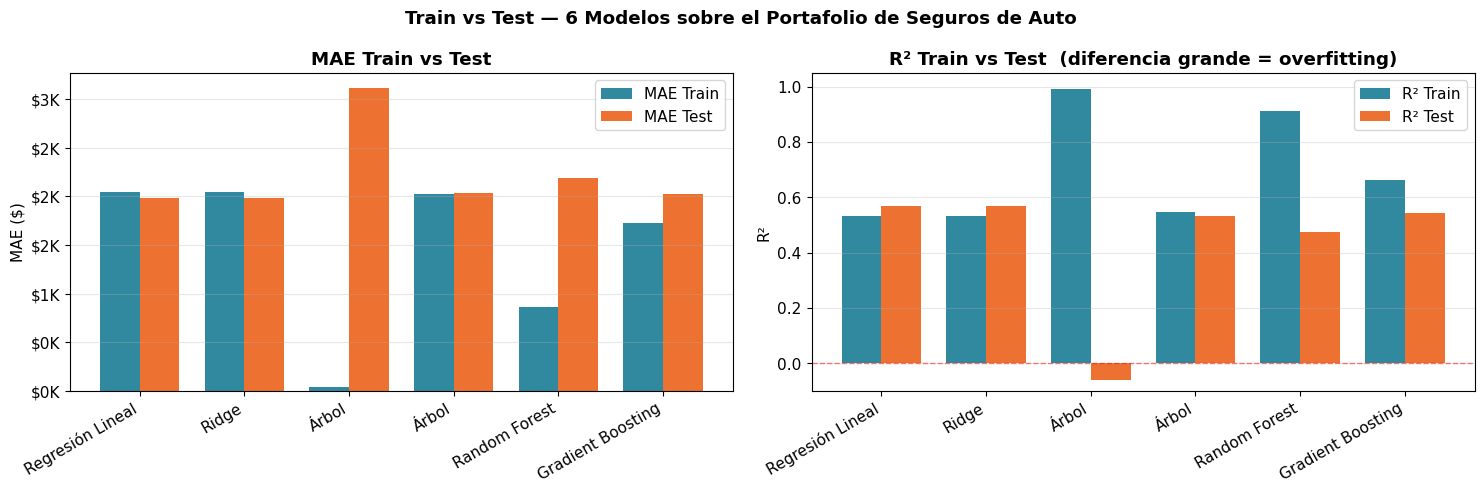

💾 Guardada: train_vs_test_modelos.png


In [9]:
# ── Visualización: MAE train vs test para todos los modelos ──────────────────
df_res = pd.DataFrame(resultados)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Train vs Test — 6 Modelos sobre el Portafolio de Seguros de Auto', fontweight='bold')

x = range(len(df_res))
labels = [m.split('(')[0].strip() for m in df_res['modelo']]

# Panel 1: MAE
ax = axes[0]
w = 0.38
bars_tr = ax.bar([i - w/2 for i in x], df_res['mae_train'], w, label='MAE Train',
                  color='#0D7490', alpha=0.85)
bars_te = ax.bar([i + w/2 for i in x], df_res['mae_test'],  w, label='MAE Test',
                  color='#EA580C', alpha=0.85)
ax.set_xticks(list(x)); ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('MAE ($)'); ax.set_title('MAE Train vs Test', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v/1000:.0f}K'))

# Panel 2: R² (muestra el overfitting visualmente)
ax = axes[1]
ax.bar([i - w/2 for i in x], df_res['r2_train'], w, label='R² Train',
        color='#0D7490', alpha=0.85)
ax.bar([i + w/2 for i in x], df_res['r2_test'],  w, label='R² Test',
        color='#EA580C', alpha=0.85)
ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xticks(list(x)); ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('R²'); ax.set_title('R² Train vs Test  (diferencia grande = overfitting)', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='y'); ax.set_ylim(-0.1, 1.05)

plt.tight_layout()
plt.savefig('train_vs_test_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Guardada: train_vs_test_modelos.png")

---
## Sección 3 — Data Leakage: demostración cuantificada

### El error más frecuente en producción

La guía del maestro dice (Sección 1.4): *"Muchos alumnos y profesionales hacen `scaler.fit_transform(X_total)` antes de separar. Esto es data leakage."*

Lo vamos a demostrar en números: el mismo modelo, los mismos datos, el mismo test set — solo cambia el **orden** de las operaciones.

In [19]:
# ═══════════════════════════════════════════════════════════════════
# EXPERIMENTO: mismo modelo, mismos datos, distinto ORDEN
# ═══════════════════════════════════════════════════════════════════

resultados_leakage = {}

# ── ❌ FORMA INCORRECTA: escalar TODO antes de separar ───────────────────────
scaler_malo = StandardScaler()
X_mal = scaler_malo.fit_transform(X)        # el scaler VE el test set
X_tr_mal, X_te_mal, y_tr_mal, y_te_mal = train_test_split(
    X_mal, y_reg, test_size=0.20, random_state=42  # misma semilla
)

for nombre, ModelClass in [
    ('Random Forest', RandomForestRegressor(n_estimators=100, random_state=20, n_jobs=-1)),
    ('Gradient Boosting', GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42)),
    ('SVM (RBF)', SVR(kernel='rbf', C=100, gamma=0.1)),
    ('Red Neuronal', MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)),
]:
    ModelClass.fit(X_tr_mal, y_tr_mal)
    mae_malo = mean_absolute_error(y_te_mal, ModelClass.predict(X_te_mal))
    resultados_leakage[nombre] = {'leakage': mae_malo}

# ── ✅ FORMA CORRECTA: separar primero, escalar por separado ─────────────────
# Usamos la misma semilla → EXACTAMENTE el mismo test set
X_tr_ok, X_te_ok, y_tr_ok, y_te_ok = train_test_split(
    X, y_reg, test_size=0.20, random_state=42
)
scaler_ok = StandardScaler()
X_tr_ok_sc = scaler_ok.fit_transform(X_tr_ok)   # fit SOLO en train
X_te_ok_sc = scaler_ok.transform(X_te_ok)        # transform en test

for nombre, ModelClass in [
    ('Random Forest', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('Gradient Boosting', GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42)),
    ('SVM (RBF)', SVR(kernel='rbf', C=100, gamma=0.1)),
    ('Red Neuronal', MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)),
]:
    ModelClass.fit(X_tr_ok_sc, y_tr_ok)
    mae_ok = mean_absolute_error(y_te_ok, ModelClass.predict(X_te_ok_sc))
    resultados_leakage[nombre]['correcto'] = mae_ok

# ── Tabla de resultados ───────────────────────────────────────────────────────
print("=" * 75)
print("  EFECTO DEL DATA LEAKAGE EN EL MAE — MISMO MODELO, MISMO TEST SET")
print("=" * 75)
print(f"\n  {'Modelo':20s}  {'❌ Con leakage':>15}  {'✅ Sin leakage':>15}  {'Diferencia':>12}  {'% optimismo'}")
print(f"  {'-'*72}")

for nombre, vals in resultados_leakage.items():
    diff = vals['leakage'] - vals['correcto']
    pct  = diff / vals['correcto'] * 100
    signo = "+" if diff >= 0 else ""
    # Nota: si leakage < correcto, el modelo parecía MEJOR de lo real
    if diff < 0:
        nota = f"← {abs(pct):.1f}% mejor de lo real (leakage lo inflaba)"
    else:
        nota = f"Diferencia mínima"
    print(f"  {nombre:20s}  ${vals['leakage']:>13,.0f}  ${vals['correcto']:>13,.0f}  "
          f"${diff:>+10,.0f}  {nota}")

print()
print("  INTERPRETACIÓN:")
print("  Si MAE(leakage) < MAE(correcto): el leakage hacía que el modelo")
print("  pareciera más preciso de lo que realmente es.")
print("  En producción (con pólizas nuevas), el desempeño real sería el correcto.")

c:\Users\aktua\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


  EFECTO DEL DATA LEAKAGE EN EL MAE — MISMO MODELO, MISMO TEST SET

  Modelo                  ❌ Con leakage    ✅ Sin leakage    Diferencia  % optimismo
  ------------------------------------------------------------------------
  Random Forest         $        2,165  $        2,187  $       -21  ← 1.0% mejor de lo real (leakage lo inflaba)
  Gradient Boosting     $        2,020  $        2,024  $        -5  ← 0.2% mejor de lo real (leakage lo inflaba)
  SVM (RBF)             $        2,103  $        2,102  $        +0  Diferencia mínima
  Red Neuronal          $        2,171  $        2,172  $        -1  ← 0.1% mejor de lo real (leakage lo inflaba)

  INTERPRETACIÓN:
  Si MAE(leakage) < MAE(correcto): el leakage hacía que el modelo
  pareciera más preciso de lo que realmente es.
  En producción (con pólizas nuevas), el desempeño real sería el correcto.


c:\Users\aktua\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


C:\Users\aktua\AppData\Local\Temp\ipykernel_39356\3177893582.py:28: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\aktua\AppData\Local\Temp\ipykernel_39356\3177893582.py:28: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\aktua\AppData\Local\Temp\ipykernel_39356\3177893582.py:29: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('data_leakage_comparacion.png', dpi=150, bbox_inches='tight')
C:\Users\aktua\AppData\Local\Temp\ipykernel_39356\3177893582.py:29: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('data_leakage_comparacion.png', dpi=150, bbox_inches='tight')
c:\Users\aktua\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\aktua\

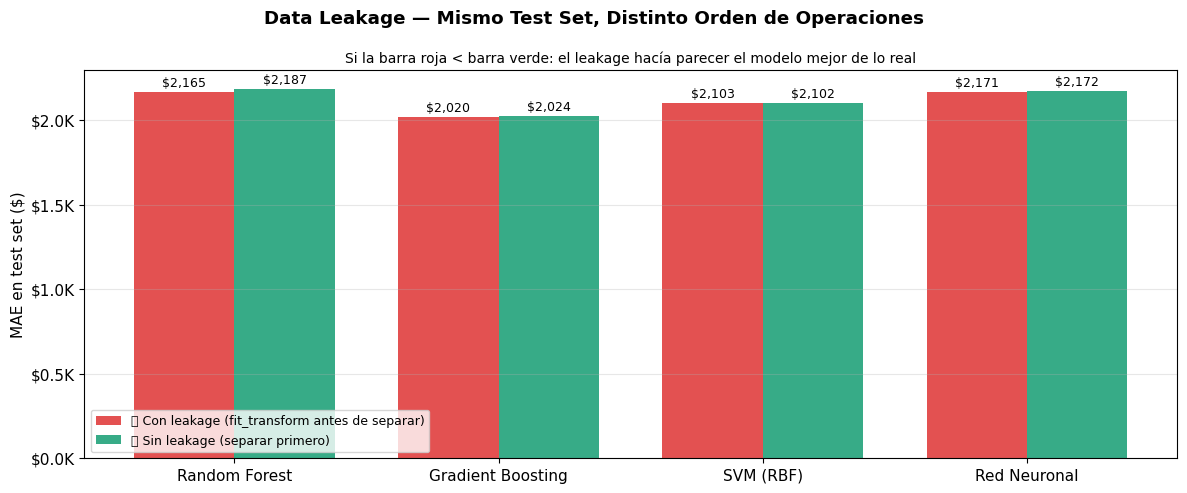

💾 Guardada: data_leakage_comparacion.png


In [20]:
# ── Visualización del leakage ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Data Leakage — Mismo Test Set, Distinto Orden de Operaciones', fontweight='bold')

nombres = list(resultados_leakage.keys())
x = np.arange(len(nombres))
w = 0.38

maes_leak = [resultados_leakage[n]['leakage']  for n in nombres]
maes_ok   = [resultados_leakage[n]['correcto'] for n in nombres]

b1 = ax.bar(x - w/2, maes_leak, w, label='❌ Con leakage (fit_transform antes de separar)',
             color='#DC2626', alpha=0.8)
b2 = ax.bar(x + w/2, maes_ok,   w, label='✅ Sin leakage (separar primero)',
             color='#059669', alpha=0.8)

for bar, val in zip(list(b1) + list(b2), maes_leak + maes_ok):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(nombres)
ax.set_ylabel('MAE en test set ($)')
ax.set_title('Si la barra roja < barra verde: el leakage hacía parecer el modelo mejor de lo real',
             fontsize=10)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v/1000:.1f}K'))

plt.tight_layout()
plt.savefig('data_leakage_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Guardada: data_leakage_comparacion.png")